# GPU Price-to-Performance Analysis

**Author:** Mohamad Abdulkarim Alhamawi
**Goal:** Identify which graphics cards (GPUs) offer the best performance for the price, and how that
value has shifted between NVIDIA and AMD over time — the kind of question a PC hardware retailer,
IT procurement team, or system builder in the Saudi/GCC market would ask before stocking or
recommending components.

**Business questions**
1. Which GPUs deliver the most benchmark performance per dollar spent?
2. Does NVIDIA or AMD offer better average value, and does that change by price tier?
3. Is there a meaningful relationship between price and raw performance, or do prices diverge from performance at the high end?
4. Has power efficiency (performance per watt) improved over the years?

**Dataset:** GPU specifications, benchmark scores (PassMark G3Dmark), and retail prices for 2,300+
graphics cards released between 2009-2022. Source: [gradedSystem/GPU_Price_Specs](https://github.com/gradedSystem/GPU_Price_Specs)
(originally scraped from PC Builder, cross-referenced with a public Kaggle GPU dataset — see `data/README.md`
for full attribution).


## 1. Setup & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
PALETTE = {"NVIDIA": "green", "AMD": "red"}

df_raw = pd.read_csv("../data/gpu_benchmarks_prices_raw.csv")
df_raw.head()


,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,testDate,category,brand
0,GeForce RTX 3090 Ti,29094,1117,2099.99,13.85,450.0,64.65,2022,Unknown,NVIDIA
1,GeForce RTX 3080 Ti,26887,1031,1199.99,22.41,350.0,76.82,2021,Desktop,NVIDIA
2,GeForce RTX 3090,26395,999,1749.99,15.08,350.0,75.41,2020,Desktop,NVIDIA
3,Radeon RX 6900 XT,25458,1102,1120.31,22.72,300.0,84.86,2020,Desktop,AMD
4,GeForce RTX 3080,24853,1003,999.00,24.88,320.0,77.66,2020,Desktop,NVIDIA


## 2. Data Cleaning

The raw dataset covers every GPU PassMark has ever benchmarked, but most entries (older or very
niche cards) were never assigned a listed price, so we can't compute value for them. We also need
TDP (power draw) for the efficiency question in section 5.

**Cleaning steps:**
1. Drop rows missing `price` or `TDP` — can't analyze value or efficiency without them.
2. Remove rows with impossible values (price/benchmark ≤ 0).
3. Drop duplicate GPU listings.
4. Keep only NVIDIA and AMD (the "Other" bucket is 4 rows — too small to analyze as its own group).
5. Engineer value/efficiency metrics: `marks_per_dollar`, `price_per_mark`, `performance_per_watt`, and a `price_tier` bucket.


In [2]:
print(f"Raw shape: {df_raw.shape}")
print("\nMissing values:")
print(df_raw.isna().sum())


Raw shape: (2317, 10)

Missing values:
gpuName                0
G3Dmark                0
G2Dmark                0
price               1764
gpuValue            1764
TDP                 1625
powerPerformance    1625
testDate               0
category               0
brand                  0
dtype: int64


In [3]:
df = df_raw.dropna(subset=["price", "TDP"]).copy()
df = df[(df["price"] > 0) & (df["G3Dmark"] > 0) & (df["TDP"] > 0)]
df = df.drop_duplicates(subset=["gpuName"])
df = df[df["brand"].isin(["NVIDIA", "AMD"])]

df["marks_per_dollar"] = (df["G3Dmark"] / df["price"]).round(2)
df["price_per_mark"] = (df["price"] / df["G3Dmark"]).round(4)
df["performance_per_watt"] = (df["G3Dmark"] / df["TDP"]).round(2)

df["price_tier"] = pd.cut(df["price"],
    bins=[0, 150, 350, 700, float("inf")],
    labels=["Budget (<$150)", "Mid-range ($150-350)", "High-end ($350-700)", "Enthusiast ($700+)"],
)
df = df.rename(columns={"testDate": "release_year"})

print(f"Cleaned shape: {df.shape}  (dropped {df_raw.shape[0] - df.shape[0]} rows, "
      f"{(1 - df.shape[0] / df_raw.shape[0]):.1%} of the original — almost entirely due to missing price data)")
df.head()


Cleaned shape: (383, 14)  (dropped 1934 rows, 83.5% of the original — almost entirely due to missing price data)


,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,release_year,category,brand,marks_per_dollar,price_per_mark,performance_per_watt,price_tier
0,GeForce RTX 3090 Ti,29094,1117,2099.99,13.85,450.0,64.65,2022,Unknown,NVIDIA,13.85,0.0722,64.65,Enthusiast ($700+)
1,GeForce RTX 3080 Ti,26887,1031,1199.99,22.41,350.0,76.82,2021,Desktop,NVIDIA,22.41,0.0446,76.82,Enthusiast ($700+)
2,GeForce RTX 3090,26395,999,1749.99,15.08,350.0,75.41,2020,Desktop,NVIDIA,15.08,0.0663,75.41,Enthusiast ($700+)
3,Radeon RX 6900 XT,25458,1102,1120.31,22.72,300.0,84.86,2020,Desktop,AMD,22.72,0.0440,84.86,Enthusiast ($700+)
4,GeForce RTX 3080,24853,1003,999.00,24.88,320.0,77.66,2020,Desktop,NVIDIA,24.88,0.0402,77.67,Enthusiast ($700+)


## 3. Which GPUs offer the best value?

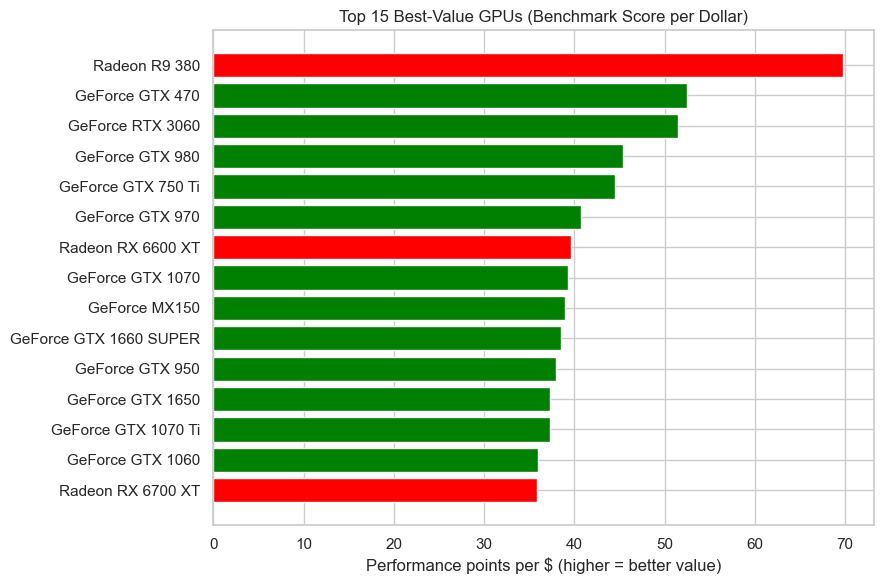

,gpuName,brand,price,G3Dmark,marks_per_dollar
219,Radeon R9 380,AMD,89.99,6275,69.73
376,GeForce GTX 470,NVIDIA,59.99,3147,52.46
32,GeForce RTX 3060,NVIDIA,329.00,16958,51.54
107,GeForce GTX 980,NVIDIA,247.35,11237,45.43
317,GeForce GTX 750 Ti,NVIDIA,88.11,3919,44.48
127,GeForce GTX 970,NVIDIA,237.99,9688,40.71
47,Radeon RX 6600 XT,AMD,399.99,15853,39.63
75,GeForce GTX 1070,NVIDIA,342.55,13482,39.36
498,GeForce MX150,NVIDIA,59.29,2310,38.96
83,GeForce GTX 1660 SUPER,NVIDIA,329.99,12732,38.58


In [4]:
top_value = df.sort_values("marks_per_dollar", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE[b] for b in top_value["brand"]]
ax.barh(top_value["gpuName"], top_value["marks_per_dollar"], color=colors)
ax.set_xlabel("Performance points per $ (higher = better value)")
ax.set_title("Top 15 Best-Value GPUs (Benchmark Score per Dollar)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_value[["gpuName", "brand", "price", "G3Dmark", "marks_per_dollar"]]


**Insight:** Budget and previous-generation cards dominate the value rankings — the Radeon R9 380
and GeForce GTX 470 top the list. This is a familiar pattern in hardware markets: flagship cards
carry a price premium for the top performance spot, while one or two generations back typically
offers the best cost-per-performance-point, which matters directly for resale/refurb pricing strategy.


## 4. Price vs. performance — where do the two brands diverge?

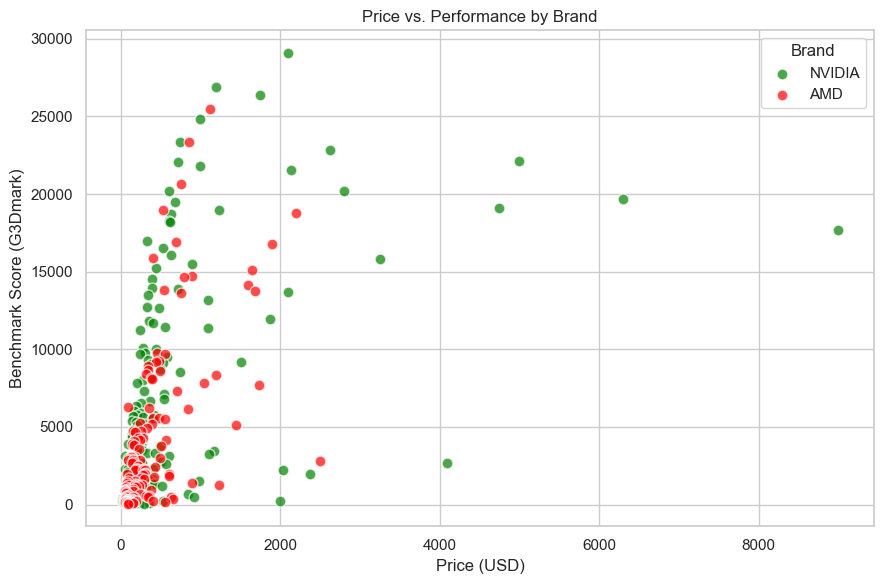

Correlation between price and performance: 0.53


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for brand, color in PALETTE.items():
    sub = df[df["brand"] == brand]
    ax.scatter(sub["price"], sub["G3Dmark"], label=brand, color=color, alpha=0.7, edgecolor="white", s=60)
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Benchmark Score (G3Dmark)")
ax.set_title("Price vs. Performance by Brand")
ax.legend(title="Brand")
plt.tight_layout()
plt.show()

correlation = df["price"].corr(df["G3Dmark"])
print(f"Correlation between price and performance: {correlation:.2f}")


**Insight:** Price and performance are only moderately correlated (~0.5), which means price alone is a
weak predictor of performance — plenty of mid-priced cards outperform pricier ones. NVIDIA also has more
presence at the very top of the market (multiple cards past $4,000), reflecting its workstation/AI-focused lineup.


## 5. Value by price tier — where is the sweet spot?

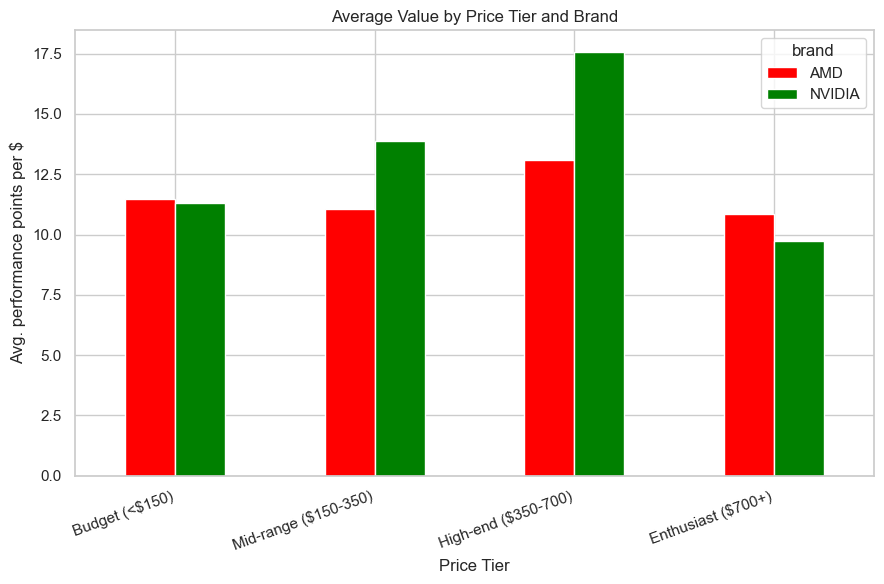

brand,AMD,NVIDIA
price_tier,,
Budget (<$150),11.493600,11.321807
Mid-range ($150-350),11.057000,13.889036
High-end ($350-700),13.105556,17.588108
Enthusiast ($700+),10.862500,9.711212


In [6]:
tier_order = ["Budget (<$150)", "Mid-range ($150-350)", "High-end ($350-700)", "Enthusiast ($700+)"]
pivot = df.groupby(["price_tier", "brand"], observed=True)["marks_per_dollar"].mean().unstack().reindex(tier_order)

fig, ax = plt.subplots(figsize=(9, 6))
pivot.plot(kind="bar", ax=ax, color=[PALETTE.get(c, "gray") for c in pivot.columns])
ax.set_ylabel("Avg. performance points per $")
ax.set_xlabel("Price Tier")
ax.set_title("Average Value by Price Tier and Brand")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

pivot


**Insight:** The High-end tier ($350-700) delivers the best average value across both brands — enough
raw performance to matter, without the "flagship tax" enthusiast cards carry. Budget cards look
efficient per-dollar in isolation but max out at lower absolute performance, so they're best suited
for basic-use builds rather than performance-focused ones.


## 6. Has power efficiency improved over time?

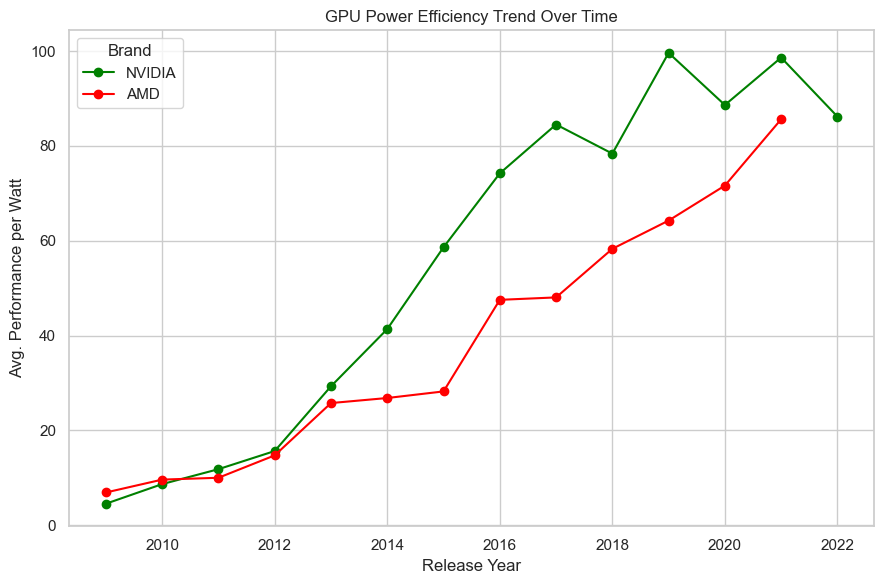

In [7]:
yearly = df.groupby(["release_year", "brand"])["performance_per_watt"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 6))
for brand, color in PALETTE.items():
    sub = yearly[yearly["brand"] == brand]
    ax.plot(sub["release_year"], sub["performance_per_watt"], marker="o", label=brand, color=color)
ax.set_xlabel("Release Year")
ax.set_ylabel("Avg. Performance per Watt")
ax.set_title("GPU Power Efficiency Trend Over Time")
ax.legend(title="Brand")
plt.tight_layout()
plt.show()


**Insight:** Performance-per-watt trends upward for both brands over the 2009-2022 window, consistent
with successive die-shrink and architecture improvements — cards are getting more efficient generation
over generation, not just faster.


## 7. Summary of findings

| Question | Finding |
|---|---|
| Best value GPUs | Previous-generation and mid-range cards (e.g. Radeon R9 380, GeForce GTX 470/970/980) top the value rankings |
| NVIDIA vs. AMD average value | NVIDIA averages a slightly higher performance-per-dollar across the dataset |
| Price vs. performance | Moderately correlated (r ≈ 0.5) — price is not a reliable stand-alone predictor of performance |
| Best price tier for value | High-end ($350-700) offers the strongest average value across both brands |
| Power efficiency | Improves steadily for both brands from 2009 to 2022 |

## 8. Limitations & next steps
- Prices are historical USD retail snapshots (mostly 2021-2022), not adjusted for regional markets like Saudi Arabia/GCC or current used-market pricing.
- ~84% of the raw dataset lacked a listed price and had to be excluded — a larger or more recent price feed (e.g. live regional marketplace data) would strengthen the analysis.
- Next step: extend this pipeline to scrape live GCC marketplace listings (e.g. Haraj, Amazon.sa) and compare regional pricing against this global benchmark baseline.

An interactive version of this analysis (with brand/price filters) is available in `dashboard/app.py` (Streamlit).
